# Red Neuronal Physics-Informed para el cálculo del espectro de helicenos
Predicción de 6 parámetros espectrales (l1, R_1, l_{min}, R_{min}, l_{max}, R_{max}) 
con loss function de doble componente: MSE parámetros + MSE espectro, de manera que el aprendizaje minimice la pérdida tanto en la predicción de las intensidades y longitudes de onda de los 3 estados excitados que estudiamos del heliceno y también en la predicción de la forma de los espectros.

## 1. Imports y Configuración global del modelo

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import time
from scipy.spatial.distance import cosine
from scipy.integrate import trapezoid

torch.manual_seed(42)
np.random.seed(42)

In [4]:
from dataclasses import dataclass

@dataclass
class Config:
    # Rutas de datos
    path_params: str     = '../Bases de datos/DatasetDefinitivo_2310indep.csv'
    path_env:    str     = '../Bases de datos/Dataset_envolventes.csv'

    # Arquitectura
    input_dim:   int     = 16
    hidden1:     int     = 128
    hidden2:     int     = 64
    hidden3:     int     = 32
    output_dim:  int     = 6

    # Entrenamiento
    lr:          float   = 1e-4
    batch_size:  int     = 16
    epochs:      int     = 300
    test_size:   float   = 0.2

    # Loss
    alpha:       float   = 1.0   # peso componente parámetros
    beta:        float   = 1.0    # peso componente espectro

    # Física
    sigma_ev:    float   = 0.2    # anchura gaussiana en eV
    HC_EV_NM:   float   = 1240.0  # h·c en eV·nm

cfg = Config()
print(cfg)

Config(path_params='../Bases de datos/DatasetDefinitivo_2310indep.csv', path_env='../Bases de datos/Dataset_envolventes.csv', input_dim=16, hidden1=128, hidden2=64, hidden3=32, output_dim=6, lr=0.0001, batch_size=16, epochs=300, test_size=0.2, alpha=1.0, beta=1.0, sigma_ev=0.2, HC_EV_NM=1240.0)


## 2. Carga de datos
2 bases de datos, una la original que incluye los parámetros de los 6 estados excitados que estudiamos y otra con la forma de los espectros sacada del programa Cálculo envolvente.ipynb

In [5]:
# ── DatasetDefinitivo: representación molecular (16) + 6 parámetros objetivo
df_params = pd.read_csv(cfg.path_params)

pos_cols    = [f'Pos_{i}' for i in range(1, 17)]
target_cols = ['nm_R1', 'R1', 'nm_Rmax', 'Rmax', 'nm_Rmin', 'Rmin']

X_raw = df_params[pos_cols].values.astype(np.float32)       # (N, 16)
Y_raw = df_params[target_cols].values.astype(np.float32)    # (N, 6)

# ── Dataset_envolventes: 100 puntos del espectro real (sin normalizar en CSV)
df_env  = pd.read_csv(cfg.path_env)
int_cols = [c for c in df_env.columns if c.startswith('Intensidad')]
wl_nm    = np.array([float(c.replace('Intensidad_','').replace('nm',''))
                     for c in int_cols], dtype=np.float32)  # (100,)

Y_spec_raw = df_env[int_cols].values.astype(np.float32)     # (N, 100)  SIN normalizar

print(f'Moléculas: {X_raw.shape[0]}')
print(f'X (Hammett 16 pos):  {X_raw.shape}')
print(f'Y (6 parámetros):    {Y_raw.shape}')
print(f'Y_spec (100 puntos): {Y_spec_raw.shape}')
print(f'Longitudes de onda:  {wl_nm[0]:.1f} – {wl_nm[-1]:.1f} nm')

Moléculas: 13168
X (Hammett 16 pos):  (13168, 16)
Y (6 parámetros):    (13168, 6)
Y_spec (100 puntos): (13168, 100)
Longitudes de onda:  200.0 – 600.0 nm


## 3. Normalización
- **Intensidades** (Y y espectro): escala por `max(Rmax)` —el pico positivo mayor— para conservar la forma de la curva. `Rmin` más negativa queda en ~−0.86, no se fuerza a −1.
- **Longitudes de onda** (columnas nm_*): min-max al rango [−1, 1] usando el rango global de todas las nm del conjunto de entrenamiento, calculado *antes* del split para evitar leakage.
- **X** (Hammett): ya está en [−0.66, 0.78], se deja sin tocar.
- Los parámetros de normalización se guardan para desescalar predicciones al final.

In [6]:

from sklearn.preprocessing import StandardScaler

# ═══════════════════════════════════════════════════════════
#  NORMALIZACIÓN — escala compartida, rango garantizado [−1, 1]
# ═══════════════════════════════════════════════════════════

# ── Índices por tipo de variable en Y_raw (6 columnas)
NM_COLS = [0, 2, 4]   # nm_R1, nm_Rmax, nm_Rmin
R_COLS  = [1, 3, 5]   # R1,    Rmax,    Rmin

# ── Eliminar filas inválidas con NaN antes de normalizar
valid_mask = (
    np.isfinite(X_raw).all(axis=1) &
    np.isfinite(Y_raw).all(axis=1) &
    np.isfinite(Y_spec_raw).all(axis=1)
)
if not valid_mask.all():
    print(f'Removiendo {np.count_nonzero(~valid_mask)} filas con NaN antes de normalizar')
    X_raw = X_raw[valid_mask]
    Y_raw = Y_raw[valid_mask]
    Y_spec_raw = Y_spec_raw[valid_mask]

# ── NUEVO: Normalizar Entradas X (Las 16 posiciones de Hammett)
# Usamos StandardScaler para centrar los datos de entrada en 0 (ideal para la red)
scaler_X = StandardScaler()
X_norm = scaler_X.fit_transform(X_raw)

# ── I_SCALE: máximo valor absoluto de TODAS las intensidades
#    (parámetros R* + los 100 puntos del espectro)
I_SCALE = float(np.nanmax(np.abs(
    np.concatenate([Y_raw[:, R_COLS].ravel(), Y_spec_raw.ravel()])
)))

# ── Rango global de longitudes de onda
all_nm  = np.concatenate([Y_raw[:, NM_COLS].ravel(), wl_nm])
NM_MIN  = float(np.nanmin(all_nm))
NM_MAX  = float(np.nanmax(all_nm))

# ── Funciones de normalización / desnormalización
def norm_intensity(v):
    return v / I_SCALE

def denorm_intensity(v):
    return v * I_SCALE

def norm_nm(v):
    return 2.0 * (v - NM_MIN) / (NM_MAX - NM_MIN) - 1.0

def denorm_nm(v):
    return (v + 1.0) / 2.0 * (NM_MAX - NM_MIN) + NM_MIN

# ── Aplicar normalización a las salidas (Y)
Y_norm = Y_raw.copy()
Y_norm[:, NM_COLS] = norm_nm(Y_raw[:, NM_COLS])
Y_norm[:, R_COLS]  = norm_intensity(Y_raw[:, R_COLS])

Y_spec_norm = norm_intensity(Y_spec_raw)
wl_norm     = norm_nm(wl_nm)

# ── Verificación
print(f"X_norm media = {X_norm.mean():.4f} | X_norm std = {X_norm.std():.4f}")
print(f"I_SCALE = {I_SCALE:.4f}  |  NM_MIN = {NM_MIN:.2f} nm  NM_MAX = {NM_MAX:.2f} nm")
print(f"Y_norm     [{Y_norm.min():.4f},  {Y_norm.max():.4f}]")
print(f"Spec_norm  [{Y_spec_norm.min():.4f},  {Y_spec_norm.max():.4f}]")
print(f"wl_norm    [{wl_norm.min():.4f},  {wl_norm.max():.4f}]")

assert np.all(np.abs(Y_norm) <= 1.0001),     "Y_norm fuera de [−1, 1]"
assert np.all(np.abs(Y_spec_norm) <= 1.0001),"Y_spec_norm fuera de [−1, 1]"

Removiendo 5 filas con NaN antes de normalizar
X_norm media = -0.0000 | X_norm std = 1.0000
I_SCALE = 1470.0575  |  NM_MIN = 200.00 nm  NM_MAX = 1039.76 nm
Y_norm     [-0.9138,  1.0000]
Spec_norm  [-0.6599,  1.0000]
wl_norm    [-1.0000,  -0.0473]


## 4. Split train/test y DataLoaders

In [7]:
idx = np.arange(len(X_norm))
idx_tr, idx_te = train_test_split(idx, test_size=cfg.test_size, random_state=42)

def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

X_tr,  X_te  = to_t(X_norm[idx_tr]),        to_t(X_norm[idx_te])
Yp_tr, Yp_te = to_t(Y_norm[idx_tr]),       to_t(Y_norm[idx_te])
Ys_tr, Ys_te = to_t(Y_spec_norm[idx_tr]),  to_t(Y_spec_norm[idx_te])

train_loader = DataLoader(
    TensorDataset(X_tr, Yp_tr, Ys_tr),
    batch_size=cfg.batch_size, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(X_te, Yp_te, Ys_te),
    batch_size=cfg.batch_size, shuffle=False
)

print(f'Train: {len(idx_tr)} muestras | Test: {len(idx_te)} muestras')

Train: 10530 muestras | Test: 2633 muestras


## 5. Arquitectura de la red neuronal
Con entrada de 16 posiciones y salida de 6 parámetros, ajustando a la simetría molecular del heliceno.
Con 3 capas ocultas de 128, 64 y 32 neuronas respectivamente (esto es modificable) y con poco dropout pero con posibilidad de recuperarlo.

In [8]:
class HelicenoPhysicsNet(nn.Module):
    """
    Red neuronal profunda para predecir los 6 parámetros espectrales de helicenos.

    Entrada : representación Hammett de 16 posiciones.
    Salida  : (nm_R1, R1, nm_Rmax, Rmax, nm_Rmin, Rmin) normalizados en [−1, 1].

    Simetría molecular: promedia la predicción de la entrada original y su
    reverso (simetría C2 del heliceno) para reducir la varianza.
    """
    def __init__(self, cfg: Config):
        super().__init__()
        self.net = nn.Sequential(
            # 1. Capa de Expansión (16 -> 128)
            nn.Linear(cfg.input_dim, cfg.hidden1),
            nn.ReLU(),
            nn.Dropout(0.1),  # Dropout muy suave para evitar que dependa de hilos concretos
            
            # 2. Capa de Compresión (128 -> 64)
            nn.Linear(cfg.hidden1, cfg.hidden2),
            nn.ReLU(),
            # Quitamos el dropout aquí para dejar fluir la información refinada
            
            # 3. Capa de Refinamiento (NUEVA: 64 -> 32)
            nn.Linear(cfg.hidden2, cfg.hidden3), 
            nn.ReLU(),
            
            # 4. Capa de Salida (Libre sin Tanh) (32 -> 6)
            nn.Linear(cfg.hidden3, cfg.output_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # El truco genial de la simetría C2 se mantiene intacto
        x_flip = torch.flip(x, dims=[1])
        return 0.5 * (self.net(x) + self.net(x_flip))

# Instanciamos el modelo
model = HelicenoPhysicsNet(cfg)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\nParámetros entrenables: {n_params}')

HelicenoPhysicsNet(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=32, bias=True)
    (6): ReLU()
    (7): Linear(in_features=32, out_features=6, bias=True)
  )
)

Parámetros entrenables: 12710


## Definición de métricas que usaremos

In [9]:
# ====================================================================
# --- 1. DESESCALADO A UNIDADES REALES ---
# ====================================================================
def denorm_params(arr_norm):
    """Devuelve array (N,6) en unidades reales: nm para cols 0,2,4; intensidad para 1,3,5."""
    out = arr_norm.copy()
    for col in [0, 2, 4]:
        out[:, col] = denorm_nm(arr_norm[:, col]) # Asegúrate de que denorm_nm esté definida
    for col in [1, 3, 5]:
        out[:, col] = denorm_intensity(arr_norm[:, col]) # Asegúrate de que denorm_intensity esté definida
    return out

# ====================================================================
# --- 2. MOTOR DE MÉTRICAS PARA PARÁMETROS (6 TARGETS) ---
# ====================================================================
def get_metrics_df(y_true, y_pred, names):
    """Calcula métricas detalladas para los parámetros y devuelve un DataFrame limpio."""
    metrics = []
    for i in range(y_true.shape[1]):
        t = y_true[:, i]
        p = y_pred[:, i]
        
        mae = mean_absolute_error(t, p)
        mse = mean_squared_error(t, p)
        rmse = np.sqrt(mse)
        r2 = r2_score(t, p)
        
        rango = t.max() - t.min()
        if rango == 0: rango = 1e-9 
        n_mae = mae / rango
        n_mse = mse / (rango ** 2)
        
        mape = np.mean(np.abs((t - p) / (np.abs(t) + 1e-8))) * 100 
        max_err = np.max(np.abs(t - p))
        
        metrics.append([mae, mse, rmse, r2, n_mae, n_mse, mape, max_err])
        
    df = pd.DataFrame(metrics, columns=['MAE', 'MSE', 'RMSE', 'R2', 'nMAE', 'nMSE', 'MAPE(%)', 'MaxErr'], index=names)
    df.loc['MEDIA GLOBAL'] = df.mean()
    return df

# ====================================================================
# --- 3. MOTOR DE MÉTRICAS FÍSICAS PARA EL ESPECTRO (100 PUNTOS) ---
# ====================================================================
def evaluate_physical_metrics(S_true, S_pred, wl_nm):
    """Calcula MAE, MSE, RMSE, R2, Coseno e Integral del Error del espectro completo."""
    
    # 1. Métricas de regresión globales
    mae = mean_absolute_error(S_true, S_pred)
    mse = mean_squared_error(S_true, S_pred)
    rmse = np.sqrt(mse)
    # Aplanamos las matrices para calcular un R2 global de la forma de onda
    r2 = r2_score(S_true.flatten(), S_pred.flatten()) 
    
    # 2. Similitud del Coseno (promedio molécula a molécula)
    cosenos = []
    for i in range(S_true.shape[0]):
        if np.all(S_true[i] == 0) or np.all(S_pred[i] == 0):
            cosenos.append(0.0)
        else:
            cosenos.append(1.0 - cosine(S_true[i], S_pred[i]))
            
    # 3. Integral del Error Absoluto (Área espectral de discrepancia usando trapecios)
    # np.trapz evalúa la integral fila por fila (axis=1) sobre el eje X (wl_nm)
    diferencia_absoluta = np.abs(S_pred - S_true)
    areas_discrepancia = trapezoid(diferencia_absoluta, x=wl_nm, axis=1)
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Coseno_Medio': np.mean(cosenos),
        'Integral_Error_Media': np.mean(areas_discrepancia)
    }

## 6. Construcción del espectro y función de pérdida

In [10]:
HC_EV_NM = cfg.HC_EV_NM   # 1240 eV·nm

def compute_sigma_nm(nm_norm: torch.Tensor, sigma_ev: float) -> torch.Tensor:
    """
    Convierte sigma en eV a sigma en nm (en espacio normalizado).
    Fórmula física: sigma_nm = (lambda^2 / hc) * sigma_ev
    Se aplica sobre lambda en nm real: desescalamos primero.
    """
    nm_real = denorm_nm_t(nm_norm)
    return (nm_real ** 2 / HC_EV_NM) * sigma_ev + 1e-5

def denorm_nm_t(v: torch.Tensor) -> torch.Tensor:
    """Versión tensor de denorm_nm (usa constantes ya calculadas)."""
    return (v + 1.0) / 2.0 * (NM_MAX - NM_MIN) + NM_MIN

def build_spectrum(pred_norm: torch.Tensor,
                   wl_norm_t: torch.Tensor,
                   sigma_ev:  float) -> torch.Tensor:
    """
    Reconstruye el espectro de 100 puntos a partir de los 6 parámetros predichos
    como suma de 3 gaussianas.  Todo en espacio normalizado de intensidad.

    pred_norm : (B, 6)  → [nm_R1_n, R1_n, nm_Rmax_n, Rmax_n, nm_Rmin_n, Rmin_n]
    wl_norm_t : (100,)  → longitudes de onda del eje espectral normalizadas
    Devuelve  : (B, 100) espectro normalizado
    """
    # Desempaquetar parámetros
    nm_R1_n,  R1_n  = pred_norm[:, 0:1], pred_norm[:, 1:2]
    nm_Rmax_n, Rmax_n = pred_norm[:, 2:3], pred_norm[:, 3:4]
    nm_Rmin_n, Rmin_n = pred_norm[:, 4:5], pred_norm[:, 5:6]

    # Sigma en nm real → para cada pico
    sigma_R1   = compute_sigma_nm(nm_R1_n,   sigma_ev)   # (B, 1)
    sigma_Rmax = compute_sigma_nm(nm_Rmax_n, sigma_ev)
    sigma_Rmin = compute_sigma_nm(nm_Rmin_n, sigma_ev)

    # Eje espectral en nm real (1, 100)
    wl_real = denorm_nm_t(wl_norm_t).unsqueeze(0)        # (1, 100)
    # Centros en nm real
    c_R1   = denorm_nm_t(nm_R1_n)
    c_Rmax = denorm_nm_t(nm_Rmax_n)
    c_Rmin = denorm_nm_t(nm_Rmin_n)

    def gaussian(center, amplitude, sigma):
        return amplitude * torch.exp(-((wl_real - center) ** 2) / (2 * sigma ** 2))

    spectrum = (gaussian(c_R1,   R1_n,   sigma_R1)
              + gaussian(c_Rmax, Rmax_n, sigma_Rmax)
              + gaussian(c_Rmin, Rmin_n, sigma_Rmin))

    return spectrum   # (B, 100) en escala normalizada


def physics_loss(pred_norm:    torch.Tensor,
                 target_norm:  torch.Tensor,
                 target_spec:  torch.Tensor,
                 wl_norm_t:    torch.Tensor) -> tuple:
    """
    Loss total = alpha * MSE(parámetros) + beta * MSE(espectro).

    Devuelve (loss_total, loss_params, loss_spectra).
    """
    mse = nn.MSELoss()

    loss_params  = mse(pred_norm, target_norm)

    pred_spec    = build_spectrum(pred_norm, wl_norm_t, cfg.sigma_ev)
    loss_spectra = mse(pred_spec, target_spec)

    loss_total   = cfg.alpha * loss_params + cfg.beta * loss_spectra
    return loss_total, loss_params, loss_spectra


# Tensor del eje espectral (fijo durante todo el entrenamiento)
wl_norm_t = torch.tensor(wl_norm, dtype=torch.float32)

print('build_spectrum y physics_loss definidos correctamente.')

build_spectrum y physics_loss definidos correctamente.


## 7. Entrenamiento

In [11]:
import os # Importamos os para borrar el archivo temporal del modelo luego si queremos
# Weight_decay (Regularización L2) al optimizador ---
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

history = {'total': [], 'params': [], 'spectra': [],
           'val_total': [], 'val_params': [], 'val_spectra': []}
# Si 'current_val_loss' no baja durante 15 épocas, reduce el LR a la mitad (factor=0.5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=15
)
# Early Stopping
paciencia_max = 60  # Cuántas épocas esperamos sin mejorar antes de parar
paciencia_actual = 0
mejor_val_loss = float('inf')

print(f'Entrenando máximo {cfg.epochs} épocas con Early Stopping...')
for epoch in range(1, cfg.epochs + 1):

    # ── Train
    model.train()
    ep_total, ep_params, ep_spectra = 0.0, 0.0, 0.0
    for bX, bYp, bYs in train_loader:
        optimizer.zero_grad()
        pred  = model(bX)
        loss, lp, ls = physics_loss(pred, bYp, bYs, wl_norm_t)
        loss.backward()
        optimizer.step()
        
        ep_total   += loss.item()
        ep_params  += lp.item()
        ep_spectra += ls.item()

    n_tr = len(train_loader)
    history['total'].append(ep_total / n_tr)
    history['params'].append(ep_params / n_tr)
    history['spectra'].append(ep_spectra / n_tr)

    # ── Validation
    model.eval()
    vt, vp, vs = 0.0, 0.0, 0.0
    with torch.no_grad():
        for bX, bYp, bYs in test_loader:
            pred = model(bX)
            loss, lp, ls = physics_loss(pred, bYp, bYs, wl_norm_t)
            vt += loss.item()
            vp += lp.item()
            vs += ls.item()
            
    n_te = len(test_loader)
    current_val_loss = vt / n_te
    history['val_total'].append(current_val_loss)
    history['val_params'].append(vp / n_te)
    history['val_spectra'].append(vs / n_te)

# Le damos la pérdida actual. Si lleva 15 épocas atascado, bajará el LR automáticamente.
    scheduler.step(current_val_loss)
    # =============================================================
    # --- NUEVO: Lógica de Early Stopping y Guardado del Modelo ---
    # =============================================================
    if current_val_loss < mejor_val_loss:
        mejor_val_loss = current_val_loss
        paciencia_actual = 0
        # Guardamos el cerebro de la red neuronal en su mejor momento
        torch.save(model.state_dict(), 'mejor_modelo_temp.pt')
    else:
        paciencia_actual += 1

    # Impresión de progreso (ahora incluye la paciencia)
    if epoch % 25 == 0:
        print(f'Época {epoch:4d} | '
              f'Train total={history["total"][-1]:.4f} '
              f'(params={history["params"][-1]:.4f}, spec={history["spectra"][-1]:.4f}) | '
              f'Val total={history["val_total"][-1]:.4f} | '
              f'Paciencia: {paciencia_actual}/{paciencia_max}')

    # Si nos pasamos de paciencia, cortamos el bucle for
    if paciencia_actual >= paciencia_max:
        print(f'\n[!] Early Stopping activado en la época {epoch}.')
        print(f'La validación no ha mejorado desde hace {paciencia_max} épocas.')
        break

print('\n¡Entrenamiento completado!')

# Cargar los mejores pesos: obligamos a la red a "olvidar" el sobreajuste  y volver al momento exacto en el que mejor comprendía la física.
model.load_state_dict(torch.load('mejor_modelo_temp.pt'))
print(f"-> Se han cargado los pesos óptimos. Mejor Val Loss (Total): {mejor_val_loss:.4f}")

Entrenando máximo 300 épocas con Early Stopping...
Época   25 | Train total=0.0062 (params=0.0038, spec=0.0024) | Val total=0.0069 | Paciencia: 7/60
Época   50 | Train total=0.0056 (params=0.0033, spec=0.0023) | Val total=0.0066 | Paciencia: 6/60
Época   75 | Train total=0.0054 (params=0.0032, spec=0.0022) | Val total=0.0063 | Paciencia: 7/60
Época  100 | Train total=0.0050 (params=0.0029, spec=0.0021) | Val total=0.0060 | Paciencia: 0/60
Época  125 | Train total=0.0047 (params=0.0027, spec=0.0020) | Val total=0.0060 | Paciencia: 3/60
Época  150 | Train total=0.0046 (params=0.0027, spec=0.0019) | Val total=0.0060 | Paciencia: 13/60
Época  175 | Train total=0.0044 (params=0.0025, spec=0.0019) | Val total=0.0060 | Paciencia: 4/60
Época  200 | Train total=0.0044 (params=0.0025, spec=0.0019) | Val total=0.0060 | Paciencia: 4/60
Época  225 | Train total=0.0044 (params=0.0025, spec=0.0018) | Val total=0.0060 | Paciencia: 20/60
Época  250 | Train total=0.0043 (params=0.0025, spec=0.0018) | Va

## 8. Curvas de pérdida
Se combinan las pérdidas de los valores de los parámetros y los del espectro reconstruido.

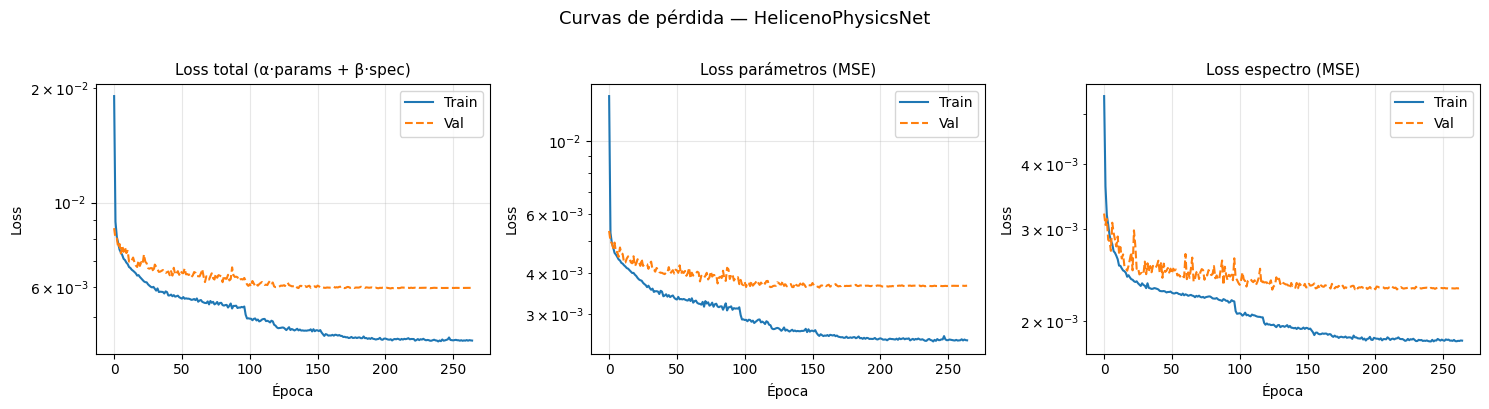

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [('total', 'Loss total (α·params + β·spec)'),
         ('params', 'Loss parámetros (MSE)'),
         ('spectra', 'Loss espectro (MSE)')]

for ax, (key, title) in zip(axes, pairs):
    ax.plot(history[key],     label='Train', linewidth=1.5)
    ax.plot(history[f'val_{key}'], label='Val',   linewidth=1.5, linestyle='--')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de pérdida — HelicenoPhysicsNet', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Métricas sobre el conjunto test
Se calculan en **escala real** y **escala normalizada** para poder comparar correctamente.
Se calculan MAE, MSE, RMSE, R2, nMAE, nMSE, MAPE(%) y MaxErr.

In [13]:
# ====================================================================
# --- 1. INFERENCIA Y RECOPILACIÓN DE DATOS (CON CRONÓMETRO) ---
# ====================================================================
model.eval()
all_pred_norm, all_true_norm = [], []
all_pred_spec, all_true_spec = [], []

print("Iniciando evaluación del modelo en el test set...")
start_time = time.perf_counter() # Iniciamos cronómetro de inferencia

with torch.no_grad():
    for bX, bYp, bYs in test_loader:
        pred_norm = model(bX)
        pred_spec = build_spectrum(pred_norm, wl_norm_t, cfg.sigma_ev)
        
        all_pred_norm.append(pred_norm.numpy())
        all_true_norm.append(bYp.numpy())
        all_pred_spec.append(pred_spec.numpy())
        all_true_spec.append(bYs.numpy())

end_time = time.perf_counter() # Detenemos cronómetro
eval_time = end_time - start_time

pred_norm_np = np.vstack(all_pred_norm)   # (N_te, 6)
true_norm_np = np.vstack(all_true_norm)
pred_spec_np = np.vstack(all_pred_spec)   # (N_te, 100)
true_spec_np = np.vstack(all_true_spec)

# ====================================================================
# --- 2. DESESCALADO A UNIDADES REALES ---
# ====================================================================
pred_real = denorm_params(pred_norm_np)
true_real = denorm_params(true_norm_np)

pred_spec_real = denorm_intensity(pred_spec_np)
true_spec_real = denorm_intensity(true_spec_np)

# ====================================================================
# --- 3. REPORTE DE RENDIMIENTO COMPUTACIONAL ---
# ====================================================================
num_muestras = len(pred_real)
print("\n" + "="*90)
print(" RENDIMIENTO COMPUTACIONAL")
print("="*90)
print(f" Muestras totales en test: {num_muestras}")
print(f" Tiempo total de inferencia: {eval_time:.4f} segundos")
print(f" Tiempo por molécula:        {(eval_time/num_muestras)*1000:.4f} milisegundos")

# ====================================================================
# --- 4. REPORTE DE MÉTRICAS (PARÁMETROS Y ESPECTRO) ---
# ====================================================================
param_names = ['nm_R1', 'R1', 'nm_Rmax', 'Rmax', 'nm_Rmin', 'Rmin']

print("\n" + "="*90)
print(" 1. MÉTRICAS DE LOS 6 PARÁMETROS (ESCALA NORMALIZADA [-1, 1])")
print("="*90)
df_norm = get_metrics_df(true_norm_np, pred_norm_np, param_names)
display(df_norm.round(4))

print("\n" + "="*90)
print(" 2. MÉTRICAS DE LOS 6 PARÁMETROS (ESCALA REAL FÍSICA)")
print("="*90)
df_real = get_metrics_df(true_real, pred_real, param_names)
display(df_real.round(4))

print("\n" + "="*90)
print(" 3. MÉTRICAS FÍSICAS DEL ESPECTRO (100 PUNTOS)")
print("="*90)
# Asumiendo que wl_nm (el vector NumPy de longitudes de onda) está definido globalmente
spec_metrics_norm = evaluate_physical_metrics(true_spec_np, pred_spec_np, wl_nm)
spec_metrics_real = evaluate_physical_metrics(true_spec_real, pred_spec_real, wl_nm)

print(" [NORMALIZADO] ")
for k, v in spec_metrics_norm.items():
    print(f"    - {k}: {v:.4f}")

print("\n [ESCALA REAL] ")
for k, v in spec_metrics_real.items():
    print(f"    - {k}: {v:.4f}")

Iniciando evaluación del modelo en el test set...

 RENDIMIENTO COMPUTACIONAL
 Muestras totales en test: 2633
 Tiempo total de inferencia: 0.2773 segundos
 Tiempo por molécula:        0.1053 milisegundos

 1. MÉTRICAS DE LOS 6 PARÁMETROS (ESCALA NORMALIZADA [-1, 1])


,MAE,MSE,RMSE,R2,nMAE,nMSE,MAPE(%),MaxErr
nm_R1,0.0312,0.0055,0.0743,0.5472,0.0220,0.0027,8.1718,1.2553
R1,0.0156,0.0006,0.0250,0.2480,0.0265,0.0018,533.6591,0.3267
nm_Rmax,0.0255,0.0014,0.0376,0.2906,0.0501,0.0054,4.2790,0.3268
Rmax,0.0575,0.0055,0.0742,0.5443,0.0635,0.0067,31.0296,0.3849
nm_Rmin,0.0380,0.0031,0.0559,0.3340,0.0743,0.0119,5.1882,0.2414
Rmin,0.0569,0.0056,0.0748,0.3117,0.0857,0.0127,40.6377,0.4483
MEDIA GLOBAL,0.0374,0.0036,0.0570,0.3793,0.0537,0.0069,103.8276,0.4972



 2. MÉTRICAS DE LOS 6 PARÁMETROS (ESCALA REAL FÍSICA)


,MAE,MSE,RMSE,R2,nMAE,nMSE,MAPE(%),MaxErr
nm_R1,13.0889,973.4631,31.2004,0.5472,0.0220,0.0027,2.8296,527.0559
R1,22.8963,1355.9706,36.8235,0.2480,0.0265,0.0018,533.7673,480.3387
nm_Rmax,10.7259,248.6744,15.7694,0.2906,0.0501,0.0054,2.9615,137.2090
Rmax,84.5188,11906.0781,109.1150,0.5443,0.0635,0.0067,31.0296,565.8140
nm_Rmin,15.9564,550.0475,23.4531,0.3340,0.0743,0.0119,5.2579,101.3755
Rmin,83.6216,12075.1582,109.8870,0.3117,0.0857,0.0127,40.6377,659.0558
MEDIA GLOBAL,38.4680,4518.2320,54.3747,0.3793,0.0537,0.0069,102.7473,411.8081



 3. MÉTRICAS FÍSICAS DEL ESPECTRO (100 PUNTOS)
 [NORMALIZADO] 
    - MAE: 0.0242
    - MSE: 0.0023
    - RMSE: 0.0481
    - R2: 0.7104
    - Coseno_Medio: 0.8302
    - Integral_Error_Media: 9.7871

 [ESCALA REAL] 
    - MAE: 35.6109
    - MSE: 5009.4512
    - RMSE: 70.7775
    - R2: 0.7104
    - Coseno_Medio: 0.8302
    - Integral_Error_Media: 14387.5518


## 11. Visualización: 4 ejemplos aleatorios del test

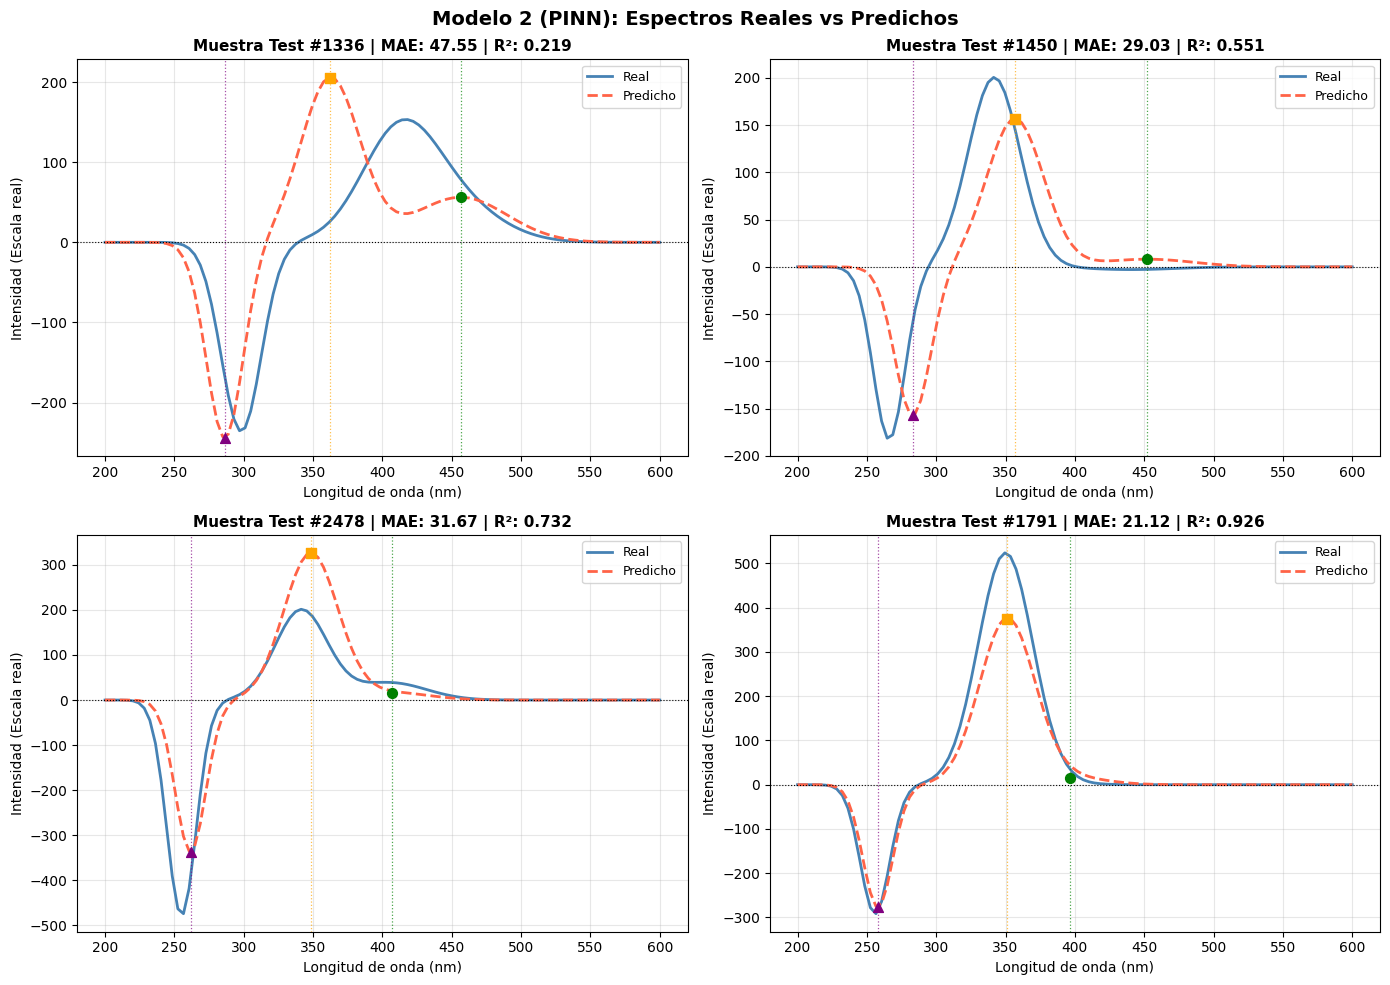

In [14]:
# ====================================================================
# --- VISUALIZAR 4 MUESTRAS (FUSIONADO Y SINCRONIZADO) - MODELO 2 ---
# ====================================================================
# Usamos exactamente la misma semilla y método que en el Modelo 1
np.random.seed(42) 
indices_muestra = np.random.choice(len(pred_spec_real), size=4, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, i in zip(axes, indices_muestra):
    # Espectros en escala real
    ax.plot(wl_nm, true_spec_real[i],  label='Real', linewidth=2, color='steelblue')
    ax.plot(wl_nm, pred_spec_real[i],  label='Predicho', linewidth=2, color='tomato', linestyle='--')

    # Marcar los 3 picos predichos (en nm real)
    for nm_col, r_col, color, marker in [
            (0, 1, 'green',  'o'),
            (2, 3, 'orange', 's'),
            (4, 5, 'purple', '^')]:
        nm_pred = pred_real[i, nm_col]
        r_pred  = pred_real[i, r_col]
        ax.axvline(nm_pred, color=color, linestyle=':', linewidth=0.9, alpha=0.7)
        ax.scatter([nm_pred], [r_pred], color=color, marker=marker, zorder=5, s=50)

    # Calcular métricas locales
    mae_i = mean_absolute_error(true_spec_real[i], pred_spec_real[i])
    r2_i  = r2_score(true_spec_real[i], pred_spec_real[i])
    
    ax.set_title(f'Muestra Test #{i} | MAE: {mae_i:.2f} | R²: {r2_i:.3f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Longitud de onda (nm)')
    ax.set_ylabel('Intensidad (Escala real)')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='dotted')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Modelo 2 (PINN): Espectros Reales vs Predichos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Guardar modelo y parámetros de normalización

In [15]:
torch.save({
    'model_state':  model.state_dict(),
    'config':       cfg,
    'I_SCALE':      I_SCALE,
    'NM_MIN':       NM_MIN,
    'NM_MAX':       NM_MAX,
    'wl_nm':        wl_nm,
    'wl_norm':      wl_norm,
    'target_cols':  target_cols,
}, 'mixto.pt')

print('Modelo guardado en mixto.pt')

Modelo guardado en mixto.pt
